# Árboles de Decisión Condicionales (Conditional Inference Trees)

**Descripción:**

Los árboles de inferencia condicional (*conditional inference trees*, **ctree**) fueron propuestos por Hothorn, Hornik y Zeileis (2006) para resolver dos defectos estructurales de los árboles clásicos (CART, C4.5): (1) el **sesgo de selección de variables** — los criterios de impureza como Gini o ganancia de información favorecen sistemáticamente a los atributos con más valores posibles o más puntos de corte, aunque no lleven más señal — y (2) el **sobreajuste por búsqueda exhaustiva**, que obliga a añadir una fase de poda posterior. La idea central de ctree es separar la decisión en dos pasos con fundamento estadístico: primero se elige la **variable** a particionar mediante un **test de hipótesis de independencia** (tests de permutación en el marco de Strasser y Weber, 1999) entre cada atributo y la respuesta, seleccionando la variable con el p-valor más bajo; solo después se busca el **mejor punto de corte** dentro de esa variable. Como los p-valores de todas las variables son comparables entre sí (a diferencia de las ganancias de impureza), la selección es **insesgada**. Además, el propio test funciona como criterio de parada: si ningún atributo muestra asociación significativa con la respuesta (tras corregir por comparaciones múltiples, p. ej. Bonferroni), el nodo se convierte en hoja — el árbol tiene un tamaño estadísticamente justificado **sin necesidad de poda**. El marco es muy general: cubre respuestas nominales, ordinales, continuas, censuradas y multivariantes con la misma maquinaria.

**Bibtex y Referencias:**

```bibtex
@article{hothorn2006unbiased,
  title={Unbiased recursive partitioning: A conditional inference framework},
  author={Hothorn, Torsten and Hornik, Kurt and Zeileis, Achim},
  journal={Journal of Computational and Graphical Statistics},
  volume={15},
  number={3},
  pages={651--674},
  year={2006},
  publisher={Taylor \& Francis}
}

@article{strasser1999asymptotic,
  title={On the asymptotic theory of permutation statistics},
  author={Strasser, Helmut and Weber, Christian},
  journal={Mathematical Methods of Statistics},
  volume={8},
  number={2},
  pages={220--250},
  year={1999}
}

@article{hothorn2015partykit,
  title={partykit: A modular toolkit for recursive partytioning in R},
  author={Hothorn, Torsten and Zeileis, Achim},
  journal={Journal of Machine Learning Research},
  volume={16},
  number={1},
  pages={3905--3909},
  year={2015}
}
```

**Tipo de Modelo:**
- **Método de aprendizaje:** Aprendizaje supervisado — clasificación y regresión (y también respuestas ordinales, censuradas/supervivencia y multivariantes, gracias al marco de tests de permutación)
- **Por parámetros:** No paramétrico — la estructura del árbol crece con los datos, pero su tamaño queda acotado estadísticamente por el nivel de significancia \\(\\alpha\\) del test (típicamente 0.05), no por hiperparámetros de poda
- **Datos de aprendizaje:** Aprendizaje por lotes (*batch*/offline) sobre datos etiquetados
- **Resultado del entrenamiento:** Aprendizaje basado en modelo (*eager learning*) — produce un árbol explícito e interpretable donde cada partición viene acompañada de su p-valor

**Alg. Entrenamiento:**
- En cada nodo se contrasta la **hipótesis global de independencia** entre la respuesta y cada uno de los \\(m\\) atributos, usando estadísticos de permutación (Strasser y Weber, 1999); los p-valores se ajustan por comparaciones múltiples (Bonferroni por defecto).
- **Parada:** si el p-valor mínimo ajustado supera \\(\\alpha\\), no hay evidencia de asociación y el nodo se declara hoja. Este es el criterio de parada — no existe fase de poda posterior.
- **Selección de variable:** si se rechaza la hipótesis global, se particiona por la variable con menor p-valor. Al comparar p-valores (y no ganancias de impureza), variables con muchos y pocos puntos de corte compiten en igualdad de condiciones — selección **insesgada**.
- **Selección de corte:** dentro de la variable elegida, se busca el punto de corte que maximiza el estadístico de la partición en dos grupos.
- Se repite recursivamente sobre cada hijo. Los dos hiperparámetros principales son \\(\\alpha\\) (`mincriterion` = 1 − \\(\\alpha\\)) y los tamaños mínimos de nodo.

**Supuestos y Restricciones:**
- Comparte los supuestos geométricos de cualquier árbol univariante: fronteras de decisión perpendiculares a los ejes, particiones binarias recursivas.
- El tamaño del árbol depende del nivel \\(\\alpha\\) y del tamaño muestral: con muestras enormes casi todo es "significativo" (árboles grandes) y con muestras pequeñas el test pierde potencia (árboles quizá demasiado pequeños). \\(\\alpha\\) juega el rol que en CART juega la poda.
- Los tests de permutación hacen el entrenamiento más costoso computacionalmente que un criterio de impureza simple.
- **No existe implementación nativa en scikit-learn.** La implementación de referencia es `ctree()` del paquete **partykit** de R (antes `party`); desde Python se accede vía `rpy2` (como haremos aquí, ya que Colab trae R y rpy2 preinstalados). En la demostración usamos además scikit-learn para evidenciar el sesgo de selección que ctree corrige.

# Demostración práctica

El plan tiene tres partes:

1. **Evidenciar el problema que ctree resuelve**: con un experimento sintético mostramos que CART (scikit-learn) elige sistemáticamente variables de ruido con muchos valores frente a variables realmente informativas con pocos valores.
2. **El ctree real**: usamos `ctree()` del paquete **partykit** de R directamente en Colab (rpy2 viene preinstalado), sobre el dataset **Pima Indians Diabetes** descargado de OpenML.
3. **Comparación con CART** sobre el mismo dataset: exactitud, tamaño del árbol y el papel de \\(\\alpha\\) como control de complejidad.

In [12]:
# En Colab scikit-learn, numpy, pandas y matplotlib ya vienen instalados.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

np.random.seed(42)  # reproducibilidad

## 1. El problema: sesgo de selección de variables en los árboles clásicos

Experimento sintético en el **caso nulo** (el mismo diseño que usan Hothorn et al. para demostrar el sesgo): la clase es aleatoria y **ninguna** de las tres variables lleva señal — una binaria, una continua con ~120 valores distintos y una categórica de 20 niveles, todas ruido puro. Un procedimiento *insesgado* debería elegir cada variable como raíz aproximadamente 1/3 de las veces (o mejor aún, negarse a particionar). Pero un criterio de impureza tipo Gini/entropía tiene *muchos más puntos de corte que probar* en la continua y en la categórica de 20 niveles que en la binaria, así que por puro azar alguna de esas particiones parecerá buena — y CART las elegirá de forma sistemáticamente desproporcionada. Ese favoritismo hacia variables con más cortes posibles, sin que aporten más información, es exactamente el sesgo que motivó a Hothorn et al. (2006); ctree lo elimina porque compara **p-valores** (comparables entre variables) en lugar de ganancias de impureza, y en este caso nulo además se negaría a particionar (ningún test resultaría significativo).

¿Qué variable elige CART como raíz? (500 repeticiones, caso nulo)
(un método insesgado daría ~0.33 a cada una)
binaria_ruido                 0.052
continua_ruido                0.628
categorica_20niveles_ruido    0.320
dtype: float64


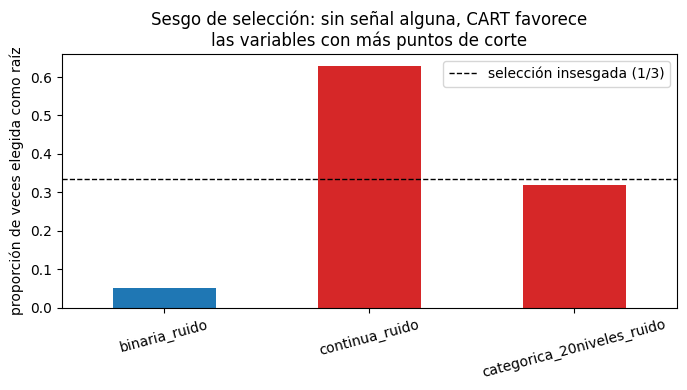

In [13]:
rng = np.random.default_rng(42)
n, repeticiones = 120, 500
nombres = ["binaria_ruido", "continua_ruido", "categorica_20niveles_ruido"]
conteo_raiz = {nombre: 0 for nombre in nombres}

for _ in range(repeticiones):
    y_sim = rng.integers(0, 2, n)         # clase aleatoria: NINGUNA variable lleva señal
    x_bin = rng.integers(0, 2, n)         # binaria (1 solo punto de corte posible)
    x_cont = rng.normal(size=n)           # continua (~120 puntos de corte posibles)
    x_cat = rng.integers(0, 20, n)        # 20 niveles (muchos cortes posibles)
    X_sim = np.column_stack([x_bin, x_cont, x_cat])

    arbol = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X_sim, y_sim)
    conteo_raiz[nombres[arbol.tree_.feature[0]]] += 1

frecuencias = pd.Series(conteo_raiz) / repeticiones
print("¿Qué variable elige CART como raíz? (500 repeticiones, caso nulo)")
print("(un método insesgado daría ~0.33 a cada una)")
print(frecuencias.round(3))

frecuencias.plot(kind="bar", figsize=(7, 4), rot=15, color=["tab:blue", "tab:red", "tab:red"])
plt.axhline(1 / 3, color="k", linestyle="--", linewidth=1, label="selección insesgada (1/3)")
plt.ylabel("proporción de veces elegida como raíz")
plt.title("Sesgo de selección: sin señal alguna, CART favorece\nlas variables con más puntos de corte")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Cargar los datos reales: Pima Indians Diabetes

Para la demostración con ctree usamos el dataset **diabetes** de OpenML (768 pacientes mujeres de origen Pima, 8 atributos clínicos numéricos: embarazos, glucosa plasmática, presión arterial, pliegue cutáneo, insulina, índice de masa corporal, función de pedigrí de diabetes y edad; objetivo binario `tested_positive`/`tested_negative`). Es el mismo dataset usado en la literatura de ctree para ilustrar árboles de inferencia condicional en clasificación. Reservamos 20 % para prueba.

In [14]:
diabetes = fetch_openml("diabetes", version=1, as_frame=True, parser="auto")
X_df = diabetes.data.astype(float)
y_ser = (diabetes.target == "tested_positive").astype(int)  # 1 = positivo en diabetes
feature_names = X_df.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y_ser.values, test_size=0.2, random_state=42, stratify=y_ser
)
print(f"Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]} | Atributos: {feature_names}")

df_preview = X_df.copy()
df_preview["diabetes"] = y_ser
df_preview.head()

Entrenamiento: 614 | Prueba: 154 | Atributos: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']


,preg,plas,pres,skin,insu,mass,pedi,age,diabetes
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


## 3. El ctree real: `partykit::ctree()` de R, ejecutado en Colab

scikit-learn no implementa árboles de inferencia condicional, y la implementación de referencia es el paquete **partykit** de R (de los propios autores del algoritmo). Colab trae R y el puente `rpy2` preinstalados, así que podemos usarlo sin salir del notebook. Primero activamos la magia de R y pasamos los datos de entrenamiento y prueba; luego instalamos partykit (tarda ~1 minuto la primera vez).

In [15]:
# Activa la "magia" de R dentro de Colab (rpy2 viene preinstalado)
%load_ext rpy2.ipython

# DataFrames que pasaremos a R: entrenamiento y prueba con la clase como factor
train_r = pd.DataFrame(X_train, columns=feature_names)
train_r["diabetes"] = np.where(y_train == 1, "positivo", "negativo")
test_r = pd.DataFrame(X_test, columns=feature_names)
test_r["diabetes"] = np.where(y_test == 1, "positivo", "negativo")
print(train_r.shape, test_r.shape)

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
(614, 9) (154, 9)


In [16]:
%%R -i train_r -i test_r
# Instala partykit (solo la primera vez; en Colab tarda ~1 min)
if (!requireNamespace("partykit", quietly = TRUE)) {
  install.packages("partykit", repos = "https://cloud.r-project.org", quiet = TRUE)
}
library(partykit)

train_r$diabetes <- factor(train_r$diabetes)
test_r$diabetes  <- factor(test_r$diabetes)

# ctree con el nivel de significancia por defecto: alpha = 0.05 (mincriterion = 0.95)
modelo_ctree <- ctree(diabetes ~ ., data = train_r)
print(modelo_ctree)


Model formula:
diabetes ~ preg + plas + pres + skin + insu + mass + pedi + age

Fitted party:
[1] root
|   [2] plas <= 154
|   |   [3] mass <= 27.3: negativo (n = 137, err = 5.1%)
|   |   [4] mass > 27.3
|   |   |   [5] age <= 30
|   |   |   |   [6] plas <= 127: negativo (n = 159, err = 13.8%)
|   |   |   |   [7] plas > 127: negativo (n = 46, err = 45.7%)
|   |   |   [8] age > 30: negativo (n = 173, err = 46.8%)
|   [9] plas > 154: positivo (n = 99, err = 16.2%)

Number of inner nodes:    4
Number of terminal nodes: 5


## 4. Visualizar el árbol condicional

La visualización nativa de partykit muestra en cada nodo interno **la variable elegida y su p-valor** (la evidencia estadística de esa partición) y en cada hoja la distribución de clases. Nótese que el árbol es compacto *sin haber aplicado poda*: los nodos donde ningún test resultó significativo simplemente dejaron de dividirse.

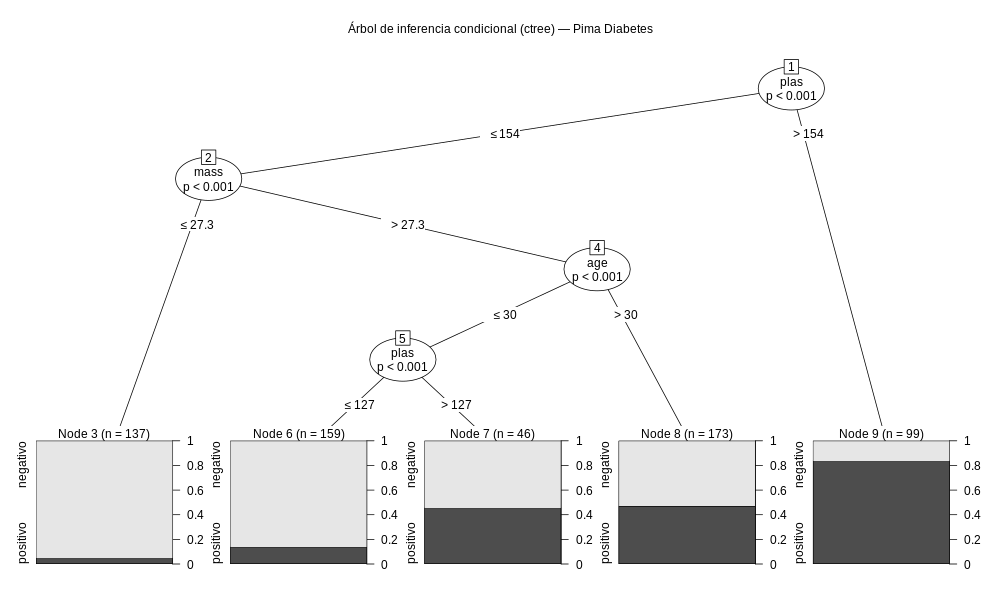

In [17]:
%%R -w 1000 -h 600
plot(modelo_ctree, main = "Árbol de inferencia condicional (ctree) — Pima Diabetes")

## 5. Evaluar ctree sobre el conjunto de prueba

Predecimos sobre las muestras de prueba (nunca vistas en el entrenamiento) y devolvemos las predicciones a Python para calcular la matriz de confusión y el reporte con las mismas herramientas que usamos con scikit-learn.

In [18]:
%%R -o pred_ctree -o hojas_ctree -o acc_train_ctree
pred_ctree <- as.character(predict(modelo_ctree, newdata = test_r))
pred_train <- as.character(predict(modelo_ctree, newdata = train_r))
acc_train_ctree <- mean(pred_train == as.character(train_r$diabetes))
hojas_ctree <- width(modelo_ctree)

cat("Exactitud ctree (test):",
    mean(pred_ctree == as.character(test_r$diabetes)), "\n")
cat("Número de hojas:", hojas_ctree,
    "| Profundidad:", depth(modelo_ctree), "\n")

Exactitud ctree (test): 0.6948052 
Número de hojas: 5 | Profundidad: 4 


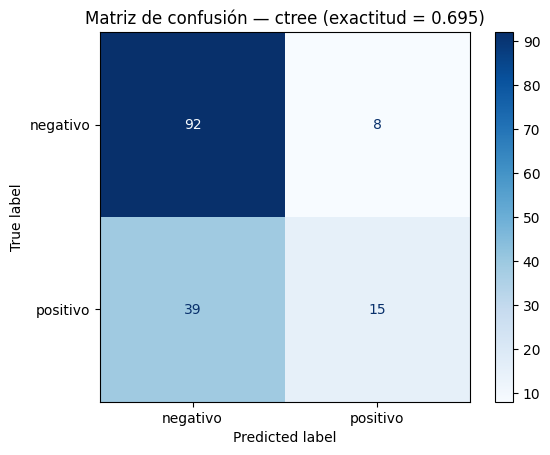

              precision    recall  f1-score   support

    negativo       0.70      0.92      0.80       100
    positivo       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



In [19]:
y_pred_ctree = (np.asarray(pred_ctree) == "positivo").astype(int)
acc_ctree = accuracy_score(y_test, y_pred_ctree)

cm = confusion_matrix(y_test, y_pred_ctree)
ConfusionMatrixDisplay(cm, display_labels=["negativo", "positivo"]).plot(cmap="Blues")
plt.title(f"Matriz de confusión — ctree (exactitud = {acc_ctree:.3f})")
plt.show()

print(classification_report(y_test, y_pred_ctree, target_names=["negativo", "positivo"]))

## 6. Comparación con CART (scikit-learn)

Entrenamos sobre los mismos datos un `DecisionTreeClassifier` sin límite de profundidad (CART puro, que necesitaría poda) y otro con una poda razonable (`ccp_alpha` elegido pequeño) para una comparación justa. El mensaje central no es la exactitud — con el \\(\\alpha\\) por defecto ctree queda algo por debajo del CART podado en este dataset, porque su criterio de parada es más conservador — sino **cómo llega cada uno a su tamaño**: CART sin podar produce un árbol enorme que memoriza el entrenamiento (exactitud 1.0 en train) y necesita que el usuario calibre la poda; ctree llega a un árbol compacto de forma automática porque los tests de significancia dejan de dividir cuando no hay evidencia. La sección siguiente muestra que relajando \\(\\alpha\\) ctree recupera (y supera) esa exactitud.

In [20]:
cart_sin_poda = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
cart_podado = DecisionTreeClassifier(ccp_alpha=0.005, random_state=42).fit(X_train, y_train)

comparacion = pd.DataFrame({
    "modelo": ["CART sin podar", "CART podado (ccp_alpha=0.005)", "ctree (alpha=0.05)"],
    "exactitud (test)": [
        accuracy_score(y_test, cart_sin_poda.predict(X_test)),
        accuracy_score(y_test, cart_podado.predict(X_test)),
        acc_ctree,
    ],
    "exactitud (train)": [
        accuracy_score(y_train, cart_sin_poda.predict(X_train)),
        accuracy_score(y_train, cart_podado.predict(X_train)),
        float(np.asarray(acc_train_ctree)[0]),
    ],
    "hojas": [
        cart_sin_poda.get_n_leaves(),
        cart_podado.get_n_leaves(),
        int(np.asarray(hojas_ctree)[0]),
    ],
})
comparacion

,modelo,exactitud (test),exactitud (train),hojas
0,CART sin podar,0.727273,1.000000,115
1,CART podado (ccp_alpha=0.005),0.753247,0.832248,13
2,ctree (alpha=0.05),0.694805,0.760586,5


## 7. El papel de \\(\\alpha\\): el "hiperparámetro de poda" estadístico

En ctree no se poda: el nivel de significancia \\(\\alpha\\) (vía `mincriterion` = 1 − \\(\\alpha\\)) decide cuánta evidencia exige cada partición. Con \\(\\alpha\\) alto (0.5) casi cualquier asociación pasa el test y el árbol crece; con \\(\\alpha\\) exigente (0.01) solo sobreviven las particiones con evidencia fuerte. Entrenamos ctree con varios niveles y observamos el compromiso tamaño/exactitud: en este dataset, relajar \\(\\alpha\\) a 0.25–0.5 produce árboles más grandes que superan en exactitud de prueba tanto al ctree por defecto como al CART podado de la sección anterior — evidencia de que \\(\\alpha\\) es un hiperparámetro que vale la pena ajustar (p. ej. por validación cruzada), igual que la poda en CART.

In [21]:
%%R
alphas <- c(0.5, 0.25, 0.10, 0.05, 0.01, 0.001)
resultados <- data.frame()
for (a in alphas) {
  m <- ctree(diabetes ~ ., data = train_r,
             control = ctree_control(mincriterion = 1 - a))
  acc <- mean(as.character(predict(m, newdata = test_r)) == as.character(test_r$diabetes))
  resultados <- rbind(resultados,
                      data.frame(alpha = a, hojas = width(m),
                                 profundidad = depth(m), exactitud_test = round(acc, 4)))
}
print(resultados)

  alpha hojas profundidad exactitud_test
1 0.500    17           8         0.7792
2 0.250    14           7         0.7792
3 0.100     7           4         0.7532
4 0.050     5           4         0.6948
5 0.010     5           4         0.6948
6 0.001     5           4         0.6948


## 8. Predecir sobre muestras nuevas

Tomamos 3 pacientes reales del conjunto de prueba (nunca vistos durante el entrenamiento) y comparamos el diagnóstico real contra el predicho por el ctree entrenado en la sección 3, mostrando sus atributos clínicos para poder seguir el camino de decisiones en el árbol de la sección 4.

In [22]:
etiquetas = {0: "negativo", 1: "positivo"}
for pos in [0, 1, 2]:  # tres pacientes de prueba, elegidos arbitrariamente
    real = etiquetas[y_test[pos]]
    predicho = pred_ctree[pos] if isinstance(pred_ctree[pos], str) else str(pred_ctree[pos])
    atributos = dict(zip(feature_names, X_test[pos]))
    print(f"Real: {real:>8} | Predicho por ctree: {predicho:>8}")
    print(f"  Atributos: {atributos}\n")

Real: negativo | Predicho por ctree: positivo
  Atributos: {'preg': np.float64(7.0), 'plas': np.float64(159.0), 'pres': np.float64(64.0), 'skin': np.float64(0.0), 'insu': np.float64(0.0), 'mass': np.float64(27.4), 'pedi': np.float64(0.294), 'age': np.float64(40.0)}

Real: negativo | Predicho por ctree: negativo
  Atributos: {'preg': np.float64(10.0), 'plas': np.float64(68.0), 'pres': np.float64(106.0), 'skin': np.float64(23.0), 'insu': np.float64(49.0), 'mass': np.float64(35.5), 'pedi': np.float64(0.285), 'age': np.float64(47.0)}

Real: negativo | Predicho por ctree: negativo
  Atributos: {'preg': np.float64(2.0), 'plas': np.float64(122.0), 'pres': np.float64(76.0), 'skin': np.float64(27.0), 'insu': np.float64(200.0), 'mass': np.float64(35.9), 'pedi': np.float64(0.483), 'age': np.float64(26.0)}



## 9. Conclusiones

- Los árboles de inferencia condicional reemplazan la maximización de impureza por **tests de hipótesis de permutación**: la variable de cada partición se elige por su p-valor y el crecimiento se detiene cuando no hay asociación estadísticamente significativa.
- Esto elimina el **sesgo de selección de variables** que demostramos en la sección 1 (en el caso nulo, CART favorece sistemáticamente las variables con más puntos de corte) y hace innecesaria la **poda**: el nivel \\(\\alpha\\) cumple ese rol con una interpretación estadística directa.
- En exactitud pura, ctree con el \\(\\alpha\\) por defecto quedó en Pima Diabetes algo por debajo de un CART bien podado (su parada es más conservadora), pero ajustando \\(\\alpha\\) los superó a ambos (sección 7) — como cualquier hiperparámetro de complejidad, conviene calibrarlo. La ventaja estructural de ctree está en la **honestidad estadística del árbol resultante** — cada partición viene justificada por un p-valor — y en su generalidad (respuestas ordinales, censuradas, multivariantes).
- La implementación de referencia es `partykit::ctree()` en R (accesible desde Colab vía rpy2); ctree es también la base de los **cforest** (random forests de árboles condicionales, con importancias de variables insesgadas).

## 10. Alternativas de implementación

- **R (referencia):** [`partykit`](https://cran.r-project.org/package=partykit) — `ctree()` y `cforest()`, mantenido por los autores del algoritmo. El paquete anterior [`party`](https://cran.r-project.org/package=party) sigue disponible.
- **Python:** no hay implementación madura equivalente; la vía práctica es `rpy2` (como aquí). Existen ports parciales de la idea en librerías experimentales, pero para un trabajo serio conviene la implementación de referencia.
- **Relacionados en scikit-learn:** no hay ctree, pero `DecisionTreeClassifier` + `cost_complexity_pruning_path` cubre la ruta clásica CART/poda con la que lo comparamos.